# Deep Momentum — Canada (Norgate)

End-to-end pipeline: load → aggregate → filter → features → walk-forward XGBoost → top-N portfolios → Mean-CVaR optimizer → diagnostics.

**Universe**: full Canadian equity market (TSX + TSX Venture + CSE + NEO), listed AND delisted (Norgate-sourced, survivorship-bias-free).

**Adjustable params at the top of the notebook** — change these to sweep configurations without touching the modules.

## 0. Master parameters
Everything tunable lives here.

In [1]:
pip install -r requirements.txt


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')

# ── Filtering ───────────────────────────────────────────────────────
LIQ_PCT          = 0.05    # bottom-X% by liquidity ratio (turnover_mt / 12mo trailing avg) dropped per month
LIQ_LOOKBACK     = 12      # months for the trailing turnover average
LIQ_MIN_PERIODS  = 6       # minimum months of history before a stock is evaluated
OPERATING_ONLY   = True    # only is_operating_company == True (Norgate classification)
EXCHANGES        = None    # e.g. ['TSX', 'TSX Venture'] to restrict; None = keep all

# ── Walk-forward training ───────────────────────────────────────────
N_ENSEMBLE       = 100     # XGBoost models trained per retraining date (paper uses 100)

# ── Portfolio (top-N, baseline EW) ──────────────────────────────────
TOP_N              = 15    # names per leg → 30-name book per month
TC_BPS             = 20.0  # one-way commission, bps of notional
CARRY_LONG_ANNUAL  = 0.05  # long financing rate (cost)
CARRY_SHORT_ANNUAL = 0.02  # short financing rate (earned; 0 for Saxo, ~2% for IBKR)
DAYS_PER_MONTH     = 30    # calendar days for monthly financing pro-rate
LONG_ONLY          = True # True = drop short leg entirely (diagnostic; avoids compounding blow-ups when shorts surge)

# ── Mean-CVaR optimizer (uses daily lookback) ───────────────────────
OPT_LOOKBACK_DAYS    = 504    # 2 years of daily history for cov / scenarios
OPT_MIN_HISTORY_DAYS = 252    # 1 year minimum per stock
OPT_CVAR_ALPHA       = 0.10   # tail mass (Vorobets convention)
OPT_W_MAX            = 0.25   # cap on any single name in a leg
OPT_B_RESAMPLES      = 200    # parameter-uncertainty bootstrap iterations
OPT_N_RESAMPLE       = 100    # draws per bootstrap mean estimate
OPT_P_FRONTIER       = 9      # frontier points
OPT_PF_INDEX         = 4      # pick this frontier point each iteration (middle of 9)
OPT_L_STACK          = 20     # Exposure Stacking folds
OPT_SCORE_COL        = 'ret_score'  # ret_score | srp_score | cvr_score | MOM_12_mt | xgb

# ── Plotting palette (Dark2-style; matches finance-data-science repo) ──
PALETTE = {
    'primary':   '#1b9e77',
    'secondary': '#7570b3',
    'tertiary':  '#d95f02',
    'accent':    '#e7298a',
    'neutral':   '#666666',
    'bg':        '#f7f7f7',
}
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.figsize':    (10, 5),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'font.size':         10,
    'legend.frameon':    False,
})

## 1. Load Norgate exports → daily parquet
Reads ~14k CA equity CSVs (listed + delisted) and the CADUSD spot series.

In [3]:
from data_load import load_norgate_equities, load_cadusd, CACHE_DIR
from pathlib import Path

DAILY_PATH = Path(CACHE_DIR) / 'ca_equities_daily.parquet'
FX_PATH    = Path(CACHE_DIR) / 'cad_fx_daily.parquet'

if not DAILY_PATH.exists():
    daily = load_norgate_equities()
    daily.to_parquet(DAILY_PATH, index=False, compression='snappy')
    fx = load_cadusd()
    if not fx.empty:
        fx.to_parquet(FX_PATH, index=False, compression='snappy')
    print(f'Wrote {DAILY_PATH}')
else:
    print(f'Cached: {DAILY_PATH} ({DAILY_PATH.stat().st_size/1e6:.0f} MB)')

Cached: /workspace/deep_momentum/cache/ca_equities_daily.parquet (680 MB)


## 2. Aggregate daily → monthly
Output columns suffixed `_mt` so daily/monthly never collide silently downstream.

In [4]:
from data_aggregate import aggregate_to_monthly, MONTHLY_PATH
import pandas as pd

if not Path(MONTHLY_PATH).exists():
    daily = pd.read_parquet(DAILY_PATH)
    monthly = aggregate_to_monthly(daily)
    monthly.to_parquet(MONTHLY_PATH, index=False, compression='snappy')
    print(f'Wrote {MONTHLY_PATH}')
else:
    print(f'Cached: {MONTHLY_PATH}')

Cached: /workspace/deep_momentum/cache/ca_equities_monthly.parquet


## 3. Filter
Zero-volume → liquidity-bottom-pct (turnover ratio) → operating companies → optional exchanges.

In [5]:
from data_filter import filter_monthly, FILTERED_PATH

monthly = pd.read_parquet(MONTHLY_PATH)
filtered = filter_monthly(
    monthly,
    liq_pct=LIQ_PCT,
    liq_lookback=LIQ_LOOKBACK,
    liq_min_periods=LIQ_MIN_PERIODS,
    operating_only=OPERATING_ONLY,
    exchanges=EXCHANGES,
)
filtered.to_parquet(FILTERED_PATH, index=False, compression='snappy')
print(f'Wrote {FILTERED_PATH}: {len(filtered):,} rows, {filtered["assetid"].nunique():,} unique assetids')


Input rows: 1,633,351, unique assetids: 14,156
  Drop NaN return_mt:  dropped 14,156 obs (first month per assetid)
  Zero-volume filter:  dropped 108 obs (0.01%)
  Liquidity filter (bottom 5% by turnover ratio, 12m lookback):
    insufficient history (<6m): 72,108 obs
    below ratio threshold:                  81,447 obs
    total dropped:                          153,555 (9.48%)
  Operating-company filter: dropped 227,859 obs (15.55%)  [ETFs/CEFs/SPACs/hybrids/derivatives]

Final: 1,237,673 rows, 10,485 unique assetids
Wrote /workspace/deep_momentum/cache/ca_filtered_monthly.parquet: 1,237,673 rows, 10,485 unique assetids


## 4. Features
Paper's 16 features (zMOM/MMOM/SMOM × 5 horizons + SIZE), plus `fwd_return_mt` and `LABEL_mt`. SIZE_mt = decile of `turnover_mt` per month (proxy for mcap).

In [6]:
from features import build_features, get_feature_columns, FEATURES_PATH

featured = build_features(filtered)
featured.to_parquet(FEATURES_PATH, index=False, compression='snappy')
FEATURE_COLS = get_feature_columns()
print(f'Wrote {FEATURES_PATH}')
print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')

  Input rows: 1,237,673, unique assetids: 10,485
  Features built in 30s
  Rows with full features + label: 717,152 (57.9% of input)
  Feature columns (16): ['zMOM_1_mt', 'zMOM_3_mt', 'zMOM_6_mt', 'zMOM_9_mt', 'zMOM_12_mt', 'MMOM_1_mt', 'MMOM_3_mt', 'MMOM_6_mt', 'MMOM_9_mt', 'MMOM_12_mt', 'SMOM_1_mt', 'SMOM_3_mt', 'SMOM_6_mt', 'SMOM_9_mt', 'SMOM_12_mt', 'SIZE_mt']
Wrote /workspace/deep_momentum/cache/ca_features_monthly.parquet
Feature columns (16): ['zMOM_1_mt', 'MMOM_1_mt', 'SMOM_1_mt', 'zMOM_3_mt', 'MMOM_3_mt', 'SMOM_3_mt', 'zMOM_6_mt', 'MMOM_6_mt', 'SMOM_6_mt', 'zMOM_9_mt', 'MMOM_9_mt', 'SMOM_9_mt', 'zMOM_12_mt', 'MMOM_12_mt', 'SMOM_12_mt', 'SIZE_mt']


## 5. Walk-forward training (XGBoost)
100-ensemble per yearly retraining, accumulating sample. **Slowest step — expect 20–60 min depending on machine.**

In [7]:
from model import run_walk_forward, PREDICTIONS_PATH

if not Path(PREDICTIONS_PATH).exists():
    predictions = run_walk_forward(featured, n_ensemble=N_ENSEMBLE, verbose=True)
    predictions.to_parquet(PREDICTIONS_PATH, index=False, compression='snappy')
    print(f'Wrote {PREDICTIONS_PATH}: {len(predictions):,} predictions')
else:
    predictions = pd.read_parquet(PREDICTIONS_PATH)
    print(f'Cached: {PREDICTIONS_PATH} ({len(predictions):,} predictions)')

# Predictions need fwd_return_mt for realised P&L; merge from the features panel
if 'fwd_return_mt' not in predictions.columns or predictions['fwd_return_mt'].isna().all():
    fwd = featured[['assetid', 'date_mt', 'fwd_return_mt']].dropna()
    predictions = predictions.drop(columns=['fwd_return_mt'], errors='ignore')
    predictions = predictions.merge(fwd, on=['assetid', 'date_mt'], how='left')

Cached: /workspace/deep_momentum/cache/ca_predictions_monthly.parquet (565,828 predictions)


## 5b. Classification quality (paper Section 4.2.1)

Confusion matrix + per-class precision/recall over the FULL OOS cross-section.
This is **separate** from the 15L/15S strategy P&L — the strategy only acts on
the corner cells (predicted class 10 → long, class 1 → short). The confusion
matrix tells you whether the XGBoost classifier is genuinely learning across
the whole distribution or just lucky on the extremes. Random baseline on the
diagonal = 10% per cell.

In [8]:
from metrics import compute_confusion_matrix, compute_classification_accuracy, print_confusion_matrix

# Predictions need fwd_return_mt + LABEL_mt; LABEL_mt comes from features
lab = featured[['assetid', 'date_mt', 'LABEL_mt']].dropna()
preds_eval = predictions.merge(lab, on=['assetid', 'date_mt'], how='left')

cm = compute_confusion_matrix(preds_eval, pred_col='xgb_class', actual_col='LABEL_mt')
acc = compute_classification_accuracy(preds_eval, pred_col='xgb_class', actual_col='LABEL_mt')

print(f'Total OOS observations: {acc["n_obs"]:,}')
print(f'Overall accuracy:        {acc["accuracy"]:.2%}  (random = 10.00%)')
print(f'Precision class 10 (H):  {acc["precision_H"]:.2%}')
print(f'Precision class  1 (L):  {acc["precision_L"]:.2%}')
print(f'Recall    class 10 (H):  {acc["recall_H"]:.2%}')
print(f'Recall    class  1 (L):  {acc["recall_L"]:.2%}')
print(f'Pred share class 10 (H): {acc["pred_ratio_H"]:.2%}')
print(f'Pred share class  1 (L): {acc["pred_ratio_L"]:.2%}')

print('\nPer-class precision and recall:')
for k in range(1, 11):
    print(f'  class {k:>2d}: precision {acc["precision"][k]:.2%}   recall {acc["recall"][k]:.2%}   pred-share {acc["pred_share"][k]:.2%}')

print('\nConfusion matrix (counts):')
print_confusion_matrix(cm, normalize=False)

print('\nConfusion matrix (row-normalised — within each predicted class, where did the actuals fall?):')
print_confusion_matrix(cm, normalize=True)

Total OOS observations: 546,519
Overall accuracy:        15.04%  (random = 10.00%)
Precision class 10 (H):  18.19%
Precision class  1 (L):  18.93%
Recall    class 10 (H):  16.99%
Recall    class  1 (L):  34.03%
Pred share class 10 (H): 7.37%
Pred share class  1 (L): 15.05%

Per-class precision and recall:
  class  1: precision 18.93%   recall 34.03%   pred-share 15.05%
  class  2: precision 13.83%   recall 14.69%   pred-share 10.23%
  class  3: precision 12.36%   recall 7.73%   pred-share 6.53%
  class  4: precision 12.44%   recall 16.88%   pred-share 15.37%
  class  5: precision 14.15%   recall 21.71%   pred-share 16.94%
  class  6: precision 16.80%   recall 19.96%   pred-share 12.52%
  class  7: precision 15.31%   recall 9.49%   pred-share 6.50%
  class  8: precision 12.79%   recall 4.78%   pred-share 3.90%
  class  9: precision 12.90%   recall 7.32%   pred-share 5.59%
  class 10: precision 18.19%   recall 16.99%   pred-share 7.37%

Confusion matrix (counts):
pred\actual        1    

## 6. Top-N portfolios — equal-weighted
Five strategies. Top-N long / bottom-N short per month, EW within each leg, costs applied per the master params.

In [11]:
from portfolio import run_all_strategies, print_performance_table

results = run_all_strategies(
    featured, predictions,
    top_n=TOP_N,
    tc_bps=TC_BPS,
    carry_long_annual=CARRY_LONG_ANNUAL,
    carry_short_annual=CARRY_SHORT_ANNUAL,
    days=DAYS_PER_MONTH,
    long_only=LONG_ONLY,
)
print_performance_table(results)

  MOM: ann.ret    4.0%  sharpe  0.09  comm  18.1bp/mo  fin  41.1bp/mo  months 419
  XGB: ann.ret  279.3%  sharpe  2.72  comm  37.9bp/mo  fin  41.1bp/mo  months 310
  RET: ann.ret  283.7%  sharpe  2.75  comm  37.8bp/mo  fin  41.1bp/mo  months 310
  SRP: ann.ret  267.2%  sharpe  3.04  comm  37.9bp/mo  fin  41.1bp/mo  months 310
  CVR: ann.ret  268.8%  sharpe  2.60  comm  37.9bp/mo  fin  41.1bp/mo  months 310

Strategy   Ann.Ret   Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months    Comm     Fin
------------------------------------------------------------------------------------------
MOM          4.0%    41.9%    0.095    -79.1%  -96.6%     0.56     419  18.1bp  41.1bp
XGB        279.3%   102.7%    2.719 2945844347587484425868279808.0%  -53.4%    13.82     310  37.9bp  41.1bp
RET        283.7%   103.3%    2.745 6744217995800113483444387840.0%  -40.0%    13.95     310  37.8bp  41.1bp
SRP        267.2%    88.0%    3.036 570934104082395345331421184.0%  -43.2%    15.43     310  37.9bp  4

### 6a. Equity curves — five strategies

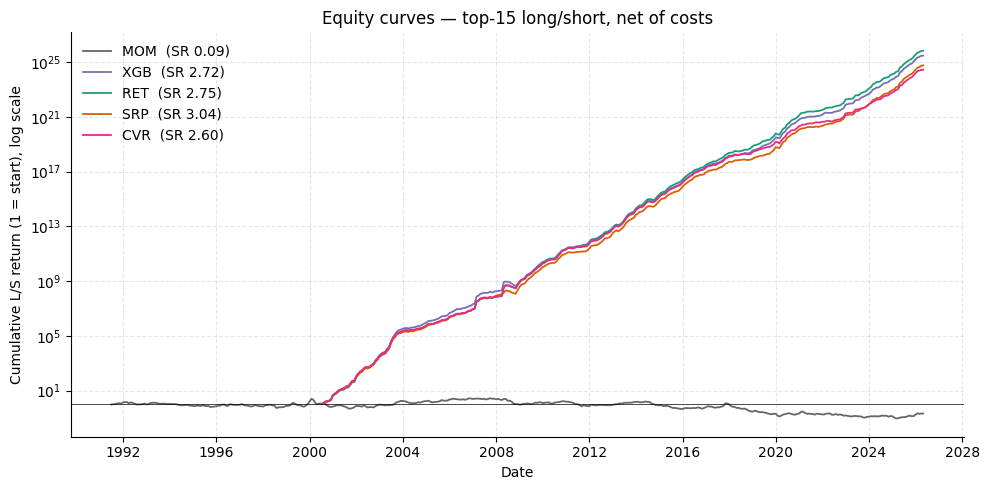

In [12]:
import numpy as np

fig, ax = plt.subplots()
colors = {
    'MOM': PALETTE['neutral'],
    'XGB': PALETTE['secondary'],
    'RET': PALETTE['primary'],
    'SRP': PALETTE['tertiary'],
    'CVR': PALETTE['accent'],
}
for name in ['MOM', 'XGB', 'RET', 'SRP', 'CVR']:
    port = results[name]['portfolio']
    if port.empty: continue
    cum = (1 + port['ls_ret']).cumprod()
    sr = results[name]['metrics']['sharpe']
    ax.plot(port['date_mt'], cum, color=colors[name], linewidth=1.3,
            label=f'{name}  (SR {sr:.2f})')
ax.set_yscale('log')
ax.axhline(1, color='black', linewidth=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative L/S return (1 = start), log scale')
ax.set_title(f'Equity curves — top-{TOP_N} long/short, net of costs')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [13]:
print(results['RET']['portfolio'][['n_long','n_short']].head())   

   n_long  n_short
0      15        0
1      15        0
2      15        0
3      15        0
4      15        0


## 7. Mean-CVaR optimizer
Vorobets-style two-leg: 2y daily lookback, parameter-uncertainty bootstrap, entropy-pooled scenarios, MeanCVaR with sample cov, Exposure Stacking. Replaces equal weights with optimised weights on the **same** stock selections.

Selection driver: **`OPT_SCORE_COL`** above (default `ret_score`).

In [24]:
from optimizer import run_two_leg_optimizer, OPT_PORT_PATH, OPT_WEIGHTS_PATH

daily = pd.read_parquet(DAILY_PATH)

opt_port, opt_weights, opt_sel_log = run_two_leg_optimizer(
    predictions, featured, daily,
    score_col=OPT_SCORE_COL,
    top_n=TOP_N,
    lookback_days=OPT_LOOKBACK_DAYS,
    min_history_days=OPT_MIN_HISTORY_DAYS,
    cvar_alpha=OPT_CVAR_ALPHA,
    w_max=OPT_W_MAX,
    B=OPT_B_RESAMPLES,
    N_resample=OPT_N_RESAMPLE,
    P=OPT_P_FRONTIER,
    pf_idx=OPT_PF_INDEX,
    L=OPT_L_STACK,
    tc_bps=TC_BPS,
    carry_long_annual=CARRY_LONG_ANNUAL,
    carry_short_annual=CARRY_SHORT_ANNUAL,
    days_per_month=DAYS_PER_MONTH,
    long_only=LONG_ONLY
)
opt_port.to_parquet(OPT_PORT_PATH, index=False, compression='snappy')
opt_weights.to_parquet(OPT_WEIGHTS_PATH, compression='snappy')

from portfolio import compute_performance
m_opt = compute_performance(opt_port, f'OPT_{OPT_SCORE_COL}')
print(f'OPT_{OPT_SCORE_COL.upper()}: ann.ret {m_opt["mean_annual"]:>7.1%}  '
      f'sharpe {m_opt["sharpe"]:>5.2f}  months {m_opt["n_months"]}')

  Building daily return panel...
  Daily panel: 9,132 days × 14,145 assetids
  Months to process: 311
    2000-07-31  1/311  (3s)
    2001-07-31  13/311  (18s)
    2002-07-31  25/311  (36s)
    2003-04-30: too few names with history (L=2, S=0) — skipped
    2003-07-31  37/311  (49s)
    2003-09-30: too few names with history (L=2, S=0) — skipped
    2003-11-28: too few names with history (L=2, S=0) — skipped
    2004-07-30  49/311  (61s)
    2005-07-29  61/311  (77s)
    2006-07-31  73/311  (95s)
    2006-08-31: too few names with history (L=2, S=0) — skipped
    2007-07-31  85/311  (111s)
    2008-07-31  97/311  (130s)
    2009-07-31  109/311  (152s)
    2010-07-30  121/311  (170s)
    2011-07-29  133/311  (187s)
    2012-07-31  145/311  (209s)
    2013-07-31  157/311  (230s)
    2014-07-31  169/311  (250s)
    2015-07-31  181/311  (270s)
    2016-07-29  193/311  (296s)
    2017-07-31  205/311  (312s)
    2018-07-31  217/311  (335s)
    2019-07-31  229/311  (360s)
    2020-07-31  241/

### 7a. EW vs Mean-CVaR — same selection, different weights

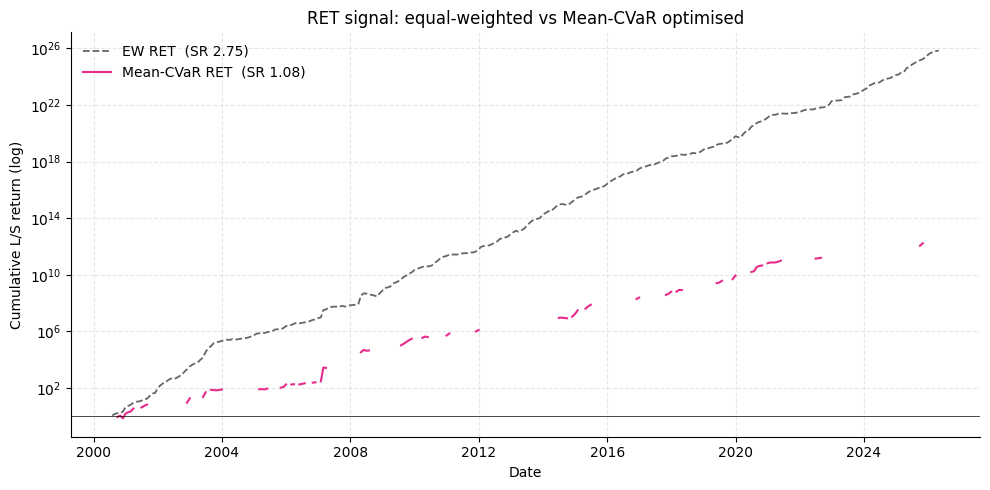

In [25]:
_score_to_strategy = {
    'ret_score':  'RET',
    'srp_score':  'SRP',
    'cvr_score':  'CVR',
    'MOM_12_mt':  'MOM',
    'xgb':        'XGB',
}
ew_strategy = _score_to_strategy.get(OPT_SCORE_COL, 'RET')
ew_port = results[ew_strategy]['portfolio']
m_ew = results[ew_strategy]['metrics']

fig, ax = plt.subplots()
if not ew_port.empty:
    cum_ew = (1 + ew_port['ls_ret']).cumprod()
    ax.plot(ew_port['date_mt'], cum_ew, color=PALETTE['neutral'],
            linestyle='--', linewidth=1.3,
            label=f'EW {ew_strategy}  (SR {m_ew["sharpe"]:.2f})')
if not opt_port.empty:
    cum_opt = (1 + opt_port['ls_ret']).cumprod()
    ax.plot(opt_port['date_mt'], cum_opt, color=PALETTE['accent'],
            linewidth=1.5,
            label=f'Mean-CVaR {ew_strategy}  (SR {m_opt["sharpe"]:.2f})')
ax.set_yscale('log')
ax.axhline(1, color='black', linewidth=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative L/S return (log)')
ax.set_title(f'{ew_strategy} signal: equal-weighted vs Mean-CVaR optimised')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 7b. Optimizer weight stability
Top-20 most-frequently-held names (by absolute weight summed over all months).

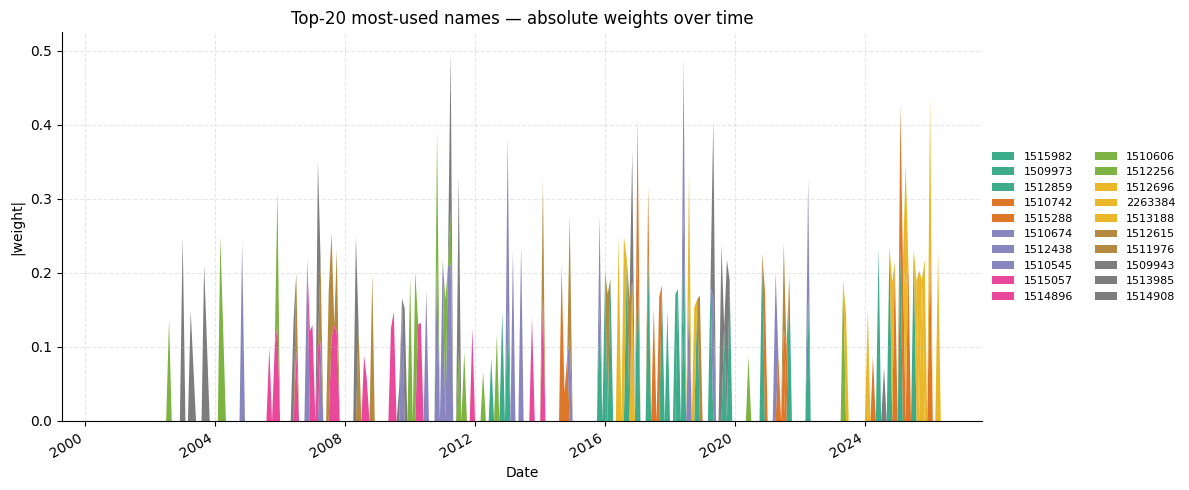

In [26]:
if not opt_weights.empty:
    abs_sum = opt_weights.abs().sum().sort_values(ascending=False)
    top_assets = abs_sum.head(20).index.tolist()
    fig, ax = plt.subplots(figsize=(12, 5))
    opt_weights[top_assets].abs().fillna(0).plot.area(
        ax=ax, linewidth=0, alpha=0.85, colormap='Dark2')
    ax.set_xlabel('Date'); ax.set_ylabel('|weight|')
    ax.set_title('Top-20 most-used names — absolute weights over time')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

## 8. Summary table

In [27]:
summary_rows = []
for name in ['MOM', 'XGB', 'RET', 'SRP', 'CVR']:
    if name in results and results[name]['metrics']:
        m = results[name]['metrics']
        summary_rows.append({'strategy': f'EW_{name}', **m})
if not opt_port.empty:
    summary_rows.append({'strategy': f'OPT_{ew_strategy}', **m_opt})
summary = pd.DataFrame(summary_rows).set_index('strategy')
display_cols = ['n_months', 'mean_annual', 'std_annual', 'sharpe',
                'cum_return', 'max_drawdown', 't_stat',
                'avg_comm_bps', 'avg_fin_bps']
summary[display_cols].round(4)

,n_months,mean_annual,std_annual,sharpe,cum_return,max_drawdown,t_stat,avg_comm_bps,avg_fin_bps
strategy,,,,,,,,,
MOM,419,0.0397,0.4193,0.0946,-7.906000e-01,-0.9663,0.5589,18.1002,41.0959
XGB,310,2.7933,1.0273,2.7190,2.945844e+25,-0.5344,13.8196,37.9097,41.0959
RET,310,2.8373,1.0335,2.7454,6.744218e+25,-0.4004,13.9539,37.7720,41.0959
SRP,310,2.6722,0.8802,3.0358,5.709341e+24,-0.4321,15.4301,37.9441,41.0959
CVR,310,2.6881,1.0358,2.5952,2.751593e+24,-0.4309,13.1903,37.8839,41.0959
OPT_ret_score,307,4.4366,4.0910,1.0845,NaN,-0.3613,5.4853,37.6424,41.0959


In [28]:
print('LONG_ONLY:', LONG_ONLY)                                                                                                                                                                                                                                                              
print('Optimizer portfolio shape:', opt_port.shape)                                                                                                                                                                                                                                         
print('n_short distribution:')                                                                                                                                                                                                                                                              
print(opt_port['n_short'].value_counts())                                                                                                                                                                                                                                                   
print('Min ls_ret seen:', opt_port['ls_ret'].min())                                                                                                                                                                                                                                         
print('How many months had ls_ret < -1?', (opt_port['ls_ret'] < -1).sum())

LONG_ONLY: True
Optimizer portfolio shape: (307, 11)
n_short distribution:
n_short
0    307
Name: count, dtype: int64
Min ls_ret seen: -0.3612762557077626
How many months had ls_ret < -1? 0


In [29]:
print('Max ls_ret:', opt_port['ls_ret'].max())
print('Mean monthly ret:', opt_port['ls_ret'].mean())                                                                                                                                                                                                                                       
print('Std monthly ret:', opt_port['ls_ret'].std())
print('Annualized return (geom):', ((1+opt_port["ls_ret"]).prod()**(12/len(opt_port)) - 1))                                                                                                                                                                                                 
print('Annualized return (arith*12):', opt_port['ls_ret'].mean()*12)                                                                                                                                                                                                                        
print('Final cumulative return:', (1+opt_port['ls_ret']).cumprod().iloc[-1])                                                                                                                                                                                                                
print()                                                                                                                                                                                                                                                                                     
  # Where exactly is the cumprod?                                                                                                                                                                                                                                                             
import pandas as pd                                                                                                                                                                                                                                                                         
cum = (1 + opt_port['ls_ret']).cumprod()                  
print('cum head:')                                                                                                                                                                                                                                                                          
print(cum.head(5))                                                                                                                                                                                                                                                                          
print('cum tail:')
print(cum.tail(5))                                                                                                                                                                                                                                                                          
print()                                                   
  # Are dates contiguous or weird?                                                                                                                                                                                                                                                            
print('First date:', opt_port['date_mt'].min())
print('Last date:', opt_port['date_mt'].max())                                                                                                                                                                                                                                              
print('n unique dates:', opt_port['date_mt'].nunique())   

Max ls_ret: 10.772696610432765
Mean monthly ret: 0.36971983861462254
Std monthly ret: 1.1809778898825056
Annualized return (geom): 2.0905703293483207
Annualized return (arith*12): 4.4366380633754705
Final cumulative return: nan

cum head:
0         NaN
1         NaN
2    0.883423
3    1.114642
4    0.711949
Name: ls_ret, dtype: float64
cum tail:
302             NaN
303    3.442085e+12
304             NaN
305             NaN
306             NaN
Name: ls_ret, dtype: float64

First date: 2000-07-31 00:00:00
Last date: 2026-05-01 00:00:00
n unique dates: 307


In [21]:
!grep -n "long_only" /workspace/deep_momentum/optimizer.py | head -10

252:                            long_only: bool = False,
338:        if long_only:
345:        # Sanity gate: long leg always required; short leg only if not long_only
346:        if len(kept_long) < 3 or (not long_only and len(kept_short) < 3):
352:        # Optimize long leg always; short leg only if not long_only.
356:        if long_only:
366:        if long_only:
371:        ls_gross = long_ret - short_ret  # long_only → ls_gross == long_ret
383:        if long_only:
389:        financing  = fin_l - fin_s   # long pays, short earns (or 0 in long_only)


In [22]:
import inspect                                                                                                                                                                                                                                                                              
src = inspect.getsource(run_two_leg_optimizer)            
print('long_only' in src)        

True


In [23]:
!grep -n "long_only" /workspace/deep_momentum/run.ipynb                                                                                                                                                                                                                                     

487:    "    long_only=LONG_ONLY,\n",
1088:      "252:                            long_only: bool = False,\n",
1089:      "338:        if long_only:\n",
1090:      "345:        # Sanity gate: long leg always required; short leg only if not long_only\n",
1091:      "346:        if len(kept_long) < 3 or (not long_only and len(kept_short) < 3):\n",
1092:      "352:        # Optimize long leg always; short leg only if not long_only.\n",
1093:      "356:        if long_only:\n",
1094:      "366:        if long_only:\n",
1095:      "371:        ls_gross = long_ret - short_ret  # long_only → ls_gross == long_ret\n",
1096:      "383:        if long_only:\n",
1097:      "389:        financing  = fin_l - fin_s   # long pays, short earns (or 0 in long_only)\n"
1102:    "!grep -n \"long_only\" /workspace/deep_momentum/optimizer.py | head -10"
1122:    "print('long_only' in src)        "


In [30]:
print('OPT_W_MAX in cell 2:', OPT_W_MAX)                                                                                                                                                                                                                                                    
print()                                                                                                                                                                                                                                                                                     
  # What was actually used in the optimizer call?                                                                                                                                                                                                                                             
import inspect                                                                                                                                                                                                                                                                              
src = inspect.getsource(run_two_leg_optimizer)            
  # Find default                                                                                                                                                                                                                                                                              
for line in src.split('\n'):                              
    if 'w_max' in line and 'def' not in line and '=' in line:                                                                                                                                                                                                                               
        print(line)                                                                                                                                                                                                                                                                         
        break
print()                                                                                                                                                                                                                                                                                     
  # What's actually in the weights data?                    
print('Max abs weight observed:', opt_weights.abs().max().max())                                                                                                                                                                                                                            
print('Top 5 individual weights:')                                                                                                                                                                                                                                                          
print(opt_weights.abs().stack().sort_values(ascending=False).head(5))           

OPT_W_MAX in cell 2: 0.25

                            w_max: float = W_MAX,

Max abs weight observed: 0.3333333333333333
Top 5 individual weights:
date_mt            
2016-11-30  1513484    0.333333
            1512795    0.333333
            2057345    0.333333
2003-01-31  2012690    0.333333
            2013406    0.333333
dtype: float64


In [31]:
!grep -n "w_max" /workspace/deep_momentum/run.ipynb | head

639:    "    w_max=OPT_W_MAX,\n",
1112:      "                            w_max: float = W_MAX,\n",
1134:    "    if 'w_max' in line and 'def' not in line and '=' in line:                                                                                                                                                                                                                               \n",


In [32]:
import pandas as pd                                                                                                                                                                                                                                                                         
n_per_month = (~opt_weights.isna()).sum(axis=1)                                                                                                                                                                                                                                             
print('Names per month — distribution:')                                                                                                                                                                                                                                                    
print(n_per_month.describe())                                                                                                                                                                                                                                                               
print()                                                                                                                                                                                                                                                                                     
print('Months with ≤ 4 names:')
print((n_per_month <= 4).sum(), 'months')                                                                                                                                                                                                                                                   
print('Months with ≤ 5 names:')                                                                                                                                                                                                                                                             
print((n_per_month <= 5).sum(), 'months')                                                                                                                                                                                                                                                   
print('Months with 15 names:')                                                                                                                                                                                                                                                              
print((n_per_month == 15).sum(), 'months')  

Names per month — distribution:
count    307.000000
mean       8.983713
std        2.609008
min        3.000000
25%        7.000000
50%        9.000000
75%       11.000000
max       15.000000
dtype: float64

Months with ≤ 4 names:
13 months
Months with ≤ 5 names:
29 months
Months with 15 names:
2 months
